# Analisis Regresi: World Values Survey (WVS) Wave 7

Notebook ini mendemonstrasikan **analisis regresi linear** di R menggunakan data WVS dari 5 negara: Indonesia, Singapura, Thailand, Kanada, dan Selandia Baru.

### Variabel

| Variabel | Tipe | Skala |
|---|---|---|
| `kepuasan_hidup` | **Dependen** | 1–10 |
| `kebebasan_memilih` | Independen (numerik) | 1–10 |
| `kepuasan_finansial` | Independen (numerik) | 1–10 |
| `usia` | Independen (numerik) | Tahun |
| `religiusitas` | Independen (kategorikal) | 4 kategori |
| `jenis_kelamin` | Independen (kategorikal) | 2 kategori |
| `negara` | Independen (kategorikal) | 5 negara |

In [1]:
library(dplyr)
library(readr)
library(ggplot2)
library(broom)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘ggplot2’ was built under R version 4.5.3 
Warning message:
package ‘broom’ was built under R version 4.5.2 


## 1. Import & Eksplorasi Data

In [15]:
# Baca & gabungkan dua dataset
wvs1 <- read_csv("data/wvs1.csv", show_col_types = FALSE)
wvs2 <- read_csv("data/wvs2.csv", show_col_types = FALSE)
wvs  <- bind_rows(wvs1, wvs2)

# Bersihkan: hapus missing codes (nilai negatif) dan NA
wvs_clean <- wvs |>
  filter(
    skala_politik >= 1,
    kebebasan_memilih >= 1,
    kepuasan_hidup >= 1,
    kepuasan_finansial >= 1,
    !is.na(religiusitas),
    !is.na(jenis_kelamin),
    jenis_kelamin %in% c("Laki-laki", "Perempuan")
  )

nrow(wvs_clean)

[1] 11874

In [16]:
# Statistik deskriptif variabel numerik
wvs_clean |>
  summarize(
    across(
      c(kepuasan_hidup, kebebasan_memilih, kepuasan_finansial, usia),
      list(M = ~mean(.x, na.rm = TRUE), SD = ~sd(.x, na.rm = TRUE),
           Min = ~min(.x, na.rm = TRUE), Max = ~max(.x, na.rm = TRUE)),
      .names = "{.col}__{.fn}"
    )
  ) |>
  tidyr::pivot_longer(
    everything(),
    names_to = c("variabel", ".value"),
    names_sep = "__"
  )

# A tibble: 4 × 5
  variabel               M    SD   Min   Max
  <chr>              <dbl> <dbl> <dbl> <dbl>
1 kepuasan_hidup      7.14  2.01     1    10
2 kebebasan_memilih   7.23  2.05     1    10
3 kepuasan_finansial  6.52  2.29     1    10
4 usia               45.9  16.1     18    93

In [17]:
# Distribusi variabel kategorikal
wvs_clean |> count(negara, sort = TRUE)
wvs_clean |> count(religiusitas, sort = TRUE)
wvs_clean |> count(jenis_kelamin)

# A tibble: 2 × 2
  jenis_kelamin     n
  <chr>         <int>
1 Laki-laki      5757
2 Perempuan      6117

## 2. Regresi Linear Sederhana

**Model:** `kepuasan_hidup ~ kebebasan_memilih`

Apakah rasa kebebasan memilih berpengaruh terhadap kepuasan hidup?

In [18]:
m1 <- lm(kepuasan_hidup ~ kebebasan_memilih, data = wvs_clean)
tidy(m1, conf.int = TRUE)

# A tibble: 2 × 7
  term              estimate std.error statistic p.value conf.low conf.high
  <chr>                <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 (Intercept)          3.68    0.0591       62.2       0    3.56      3.80 
2 kebebasan_memilih    0.479   0.00787      60.9       0    0.464     0.495

In [19]:
# R-squared & ringkasan model
glance(m1) |>
  select(r.squared, adj.r.squared, sigma, statistic, p.value, nobs)

# A tibble: 1 × 6
  r.squared adj.r.squared sigma statistic p.value  nobs
      <dbl>         <dbl> <dbl>     <dbl>   <dbl> <int>
1     0.238         0.238  1.76     3705.       0 11874

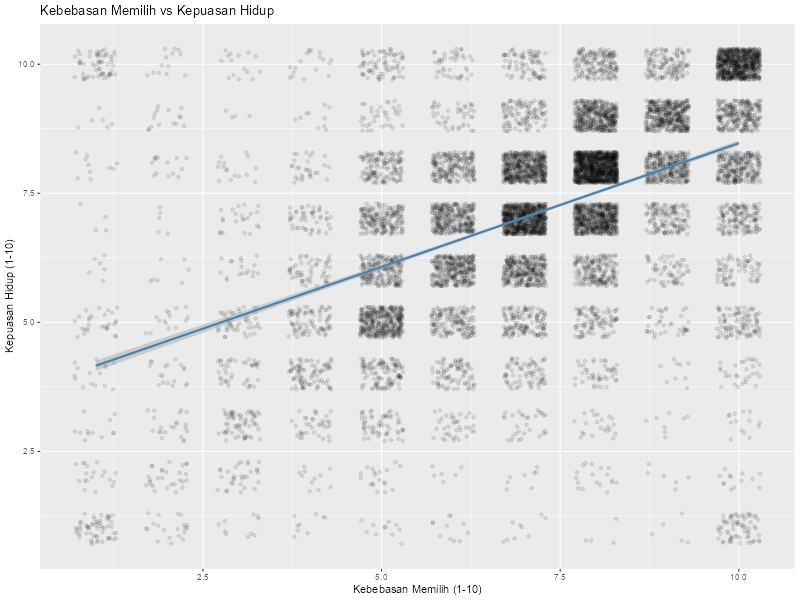

`geom_smooth()` using formula = 'y ~ x'

In [20]:
# Visualisasi
ggplot(wvs_clean, aes(x = kebebasan_memilih, y = kepuasan_hidup)) +
  geom_jitter(alpha = 0.1, width = 0.3, height = 0.3) +
  geom_smooth(method = "lm", color = "steelblue") +
  labs(
    title = "Kebebasan Memilih vs Kepuasan Hidup",
    x = "Kebebasan Memilih (1-10)",
    y = "Kepuasan Hidup (1-10)"
  )

### Interpretasi Regresi Sederhana

- **Intercept (β₀)**: Prediksi kepuasan hidup ketika kebebasan memilih = 0
- **Slope (β₁)**: Setiap kenaikan 1 poin kebebasan memilih, kepuasan hidup berubah sebesar β₁
- **R²**: Proporsi varians kepuasan hidup yang dijelaskan oleh kebebasan memilih

## 3. Regresi Linear Berganda

Tambahkan prediktor numerik lainnya.

In [21]:
m2 <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia,
         data = wvs_clean)
tidy(m2, conf.int = TRUE)

# A tibble: 4 × 7
  term               estimate std.error statistic   p.value conf.low conf.high
  <chr>                 <dbl>     <dbl>     <dbl>     <dbl>    <dbl>     <dbl>
1 (Intercept)         2.11     0.0680       31.0  2.27e-203 1.98       2.24   
2 kebebasan_memilih   0.312    0.00734      42.5  0         0.297      0.326  
3 kepuasan_finansial  0.410    0.00660      62.1  0         0.397      0.423  
4 usia                0.00229  0.000874      2.62 8.76e-  3 0.000578   0.00400

In [22]:
# Perbandingan model M1 vs M2
bind_rows(
  glance(m1) |> mutate(model = "M1: Sederhana"),
  glance(m2) |> mutate(model = "M2: Berganda")
) |>
  select(model, r.squared, adj.r.squared, AIC, BIC)

# A tibble: 2 × 5
  model         r.squared adj.r.squared    AIC    BIC
  <chr>             <dbl>         <dbl>  <dbl>  <dbl>
1 M1: Sederhana     0.238         0.238 47103. 47125.
2 M2: Berganda      0.427         0.427 43697. 43734.

## 4. Regresi dengan Variabel Kategorikal

R secara otomatis membuat *dummy variables* untuk variabel `character`/`factor`. Kategori pertama (alfabet) menjadi referensi.

In [23]:
# Model lengkap dengan variabel kategorikal
m3 <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia +
           religiusitas + jenis_kelamin + negara,
         data = wvs_clean)
tidy(m3, conf.int = TRUE)

# A tibble: 12 × 7
   term                estimate std.error statistic   p.value conf.low conf.high
   <chr>                  <dbl>     <dbl>     <dbl>     <dbl>    <dbl>     <dbl>
 1 (Intercept)          2.23     0.0864       25.8  9.34e-143  2.06      2.40   
 2 kebebasan_memilih    0.300    0.00747      40.2  0          0.286     0.315  
 3 kepuasan_finansial   0.410    0.00655      62.6  0          0.397     0.423  
 4 usia                 0.00406  0.000912      4.45 8.61e-  6  0.00227   0.00585
 5 religiusitasReligi…  0.188    0.0495        3.81 1.41e-  4  0.0914    0.285  
 6 religiusitasTidak …  0.0877   0.0489        1.79 7.30e-  2 -0.00817   0.184  
 7 religiusitasTidak …  0.199    0.197         1.01 3.13e-  1 -0.187     0.585  
 8 jenis_kelaminPerem…  0.0794   0.0279        2.84 4.51e-  3  0.0246    0.134  
 9 negaraKanada        -0.424    0.0429       -9.89 5.58e- 23 -0.509    -0.340  
10 negaraSelandia Baru -0.282    0.0690       -4.08 4.54e-  5 -0.417    -0.146  
11 negara

In [25]:
# Fit ulang M1 & M2 pada subset yang sama agar bisa dibandingkan
dat_complete <- wvs_clean |>
  select(kepuasan_hidup, kebebasan_memilih, kepuasan_finansial, usia,
         religiusitas, jenis_kelamin, negara) |>
  tidyr::drop_na()

m1b <- lm(kepuasan_hidup ~ kebebasan_memilih, data = dat_complete)
m2b <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia,
           data = dat_complete)
m3b <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia +
             religiusitas + jenis_kelamin + negara, data = dat_complete)

anova(m1b, m2b, m3b)

Analysis of Variance Table

Model 1: kepuasan_hidup ~ kebebasan_memilih
Model 2: kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia
Model 3: kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia + 
    religiusitas + jenis_kelamin + negara
  Res.Df   RSS Df Sum of Sq        F    Pr(>F)    
1  11866 36698                                    
2  11864 27579  2    9119.1 1997.473 < 2.2e-16 ***
3  11856 27063  8     515.6   28.234 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [26]:
# R-squared ketiga model
bind_rows(
  glance(m1b) |> mutate(model = "M1: Sederhana"),
  glance(m2b) |> mutate(model = "M2: Berganda"),
  glance(m3b) |> mutate(model = "M3: + Kategorikal")
) |>
  select(model, r.squared, adj.r.squared, AIC, BIC, nobs)

# A tibble: 3 × 6
  model             r.squared adj.r.squared    AIC    BIC  nobs
  <chr>                 <dbl>         <dbl>  <dbl>  <dbl> <int>
1 M1: Sederhana         0.238         0.238 47083. 47106. 11868
2 M2: Berganda          0.427         0.427 43697. 43734. 11868
3 M3: + Kategorikal     0.438         0.437 43489. 43585. 11868

## 5. Diagnostik Model

Periksa asumsi regresi:
1. **Linearitas** — Residual vs Fitted
2. **Normalitas** — Q-Q plot residual
3. **Homoskedastisitas** — Spread residual konstan
4. **Multikolinearitas** — VIF < 5

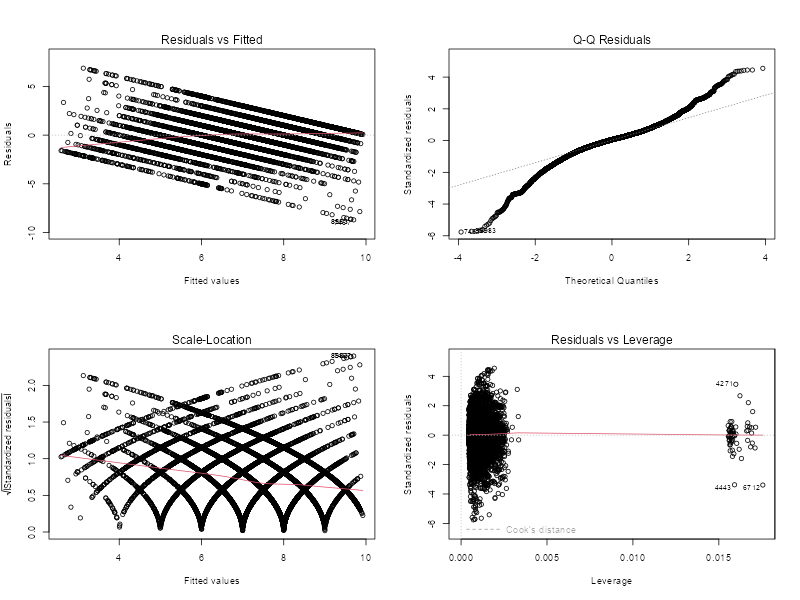

In [27]:
# Diagnostic plots
par(mfrow = c(2, 2))
plot(m3b)

In [28]:
# Variance Inflation Factor (VIF)
car::vif(m3b)

                       GVIF Df GVIF^(1/(2*Df))
kebebasan_memilih  1.219331  1        1.104233
kepuasan_finansial 1.169704  1        1.081529
usia               1.117953  1        1.057333
religiusitas       1.420681  3        1.060269
jenis_kelamin      1.014035  1        1.006993
negara             1.615303  4        1.061773

## 6. Interpretasi Hasil

### A. Perbandingan Model (ANOVA & R²)

| Model | R² | Adj. R² | AIC | Perubahan |
|---|---|---|---|---|
| M1: Sederhana | 0.238 | 0.238 | 47 083 | — |
| M2: Berganda | 0.427 | 0.427 | 43 697 | ΔR² = +0.189*** |
| M3: + Kategorikal | 0.438 | 0.437 | 43 489 | ΔR² = +0.011*** |

- Penambahan `kepuasan_finansial` dan `usia` (M2) menaikkan R² hampir dua kali lipat — perbaikan paling besar.
- Variabel kategorikal (M3) secara statistik signifikan (F-test p < 0.001) meskipun peningkatan R² relatif kecil (+1.1 pp), menunjukkan bahwa negara dan demografi memang menambah daya jelas.

### B. Koefisien Kunci (Model Penuh M3)

| Prediktor | β | Interpretasi |
|---|---|---|
| `kebebasan_memilih` | 0.300*** | Setiap kenaikan 1 poin kebebasan memilih, kepuasan hidup naik ≈ 0.30, *ceteris paribus* |
| `kepuasan_finansial` | 0.410*** | Prediktor terkuat — setiap kenaikan 1 poin kepuasan finansial, kepuasan hidup naik ≈ 0.41 |
| `usia` | 0.004*** | Efek kecil tapi signifikan; setiap tambahan 10 tahun usia, kepuasan hidup naik ≈ 0.04 |
| `religiusitas: Religius` | 0.188* | Orang religius sedikit lebih puas dibanding non-religius (referensi) |
| `jenis_kelamin: Perempuan` | 0.079* | Perempuan sedikit lebih puas dibanding laki-laki |
| `negara: Kanada` | −0.424*** | Rata-rata lebih rendah ~0.4 poin dibanding Singapura (referensi) |
| `negara: Thailand` | −0.498*** | Rata-rata lebih rendah ~0.5 poin dibanding Singapura |

### C. Diagnostik

- **VIF**: Semua GVIF^(1/2Df) < 1.11 → **tidak ada masalah multikolinearitas**.
- **Residuals vs Fitted**: Pola "garis-garis" terlihat karena variabel dependen berupa skala integer 1-10 (bukan kontinu murni). Ini normal untuk data survei Likert.
- **Q-Q Plot**: Ekor bawah sedikit melengkung — distribusi residual sedikit *left-skewed* (banyak responden memberi skor tinggi). Dengan n > 11 000, ini tidak mengganggu inferensi (CLT).
- **Leverage**: Tidak ada titik yang melampaui Cook's distance 0.5 → tidak ada observasi berpengaruh ekstrem.

### D. Kesimpulan Substantif

1. **Kepuasan finansial** adalah prediktor paling kuat terhadap kepuasan hidup, diikuti **kebebasan memilih** — sejalan dengan teori *subjective well-being* (Diener et al.).
2. Usia memiliki efek positif kecil — konsisten dengan "U-shape" kebahagiaan (di sini kita hanya memodelkan efek linier).
3. Terdapat **perbedaan antar-negara yang signifikan** setelah mengontrol variabel individual, menunjukkan faktor kontekstual/institusional berperan.
4. R² = 0.44 menunjukkan model menjelaskan ~44% variasi kepuasan hidup — cukup baik untuk data survei lintas-negara.

### Membaca Diagnostic Plots

| Plot | Asumsi | Baik jika... |
|---|---|---|
| Residuals vs Fitted | Linearitas | Titik-titik tersebar acak, garis merah horizontal |
| Normal Q-Q | Normalitas | Titik-titik mengikuti garis diagonal |
| Scale-Location | Homoskedastisitas | Titik-titik tersebar merata, garis merah horizontal |
| Residuals vs Leverage | Outlier/Influential | Tidak ada titik di luar Cook's distance |

## 6. Interpretasi

### Cara Membaca Koefisien

- **Numerik** (misal `kebebasan_memilih`): Setiap kenaikan 1 poin, `kepuasan_hidup` berubah β poin, *ceteris paribus*
- **Kategorikal** (misal `negaraKanada`): Rata-rata `kepuasan_hidup` responden Kanada lebih tinggi/rendah β poin dibanding kategori referensi, *ceteris paribus*
- **p-value** < 0.05: Koefisien signifikan berbeda dari nol
- **R² adjusted**: Proporsi varians yang dijelaskan, disesuaikan jumlah prediktor
- **AIC/BIC**: Semakin kecil semakin baik (untuk perbandingan model)

## 7. Latihan

### Latihan 1: Efek Interaksi

Uji apakah hubungan `kebebasan_memilih → kepuasan_hidup` berbeda antar negara.

```r
m4 <- lm(kepuasan_hidup ~ kebebasan_memilih * negara +
           kepuasan_finansial + usia,
         data = wvs_clean)
# tidy(m4, conf.int = TRUE)
# anova(m3, m4)
```

### Latihan 2: Analisis per Negara

Jalankan regresi M2 hanya untuk Indonesia dan bandingkan dengan Singapura.

```r
wvs_idn <- wvs_clean |> filter(negara == "Indonesia")
wvs_sgp <- wvs_clean |> filter(negara == "Singapura")

# m_idn <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia,
#             data = wvs_idn)
# m_sgp <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial + usia,
#             data = wvs_sgp)
# tidy(m_idn)
# tidy(m_sgp)
```

### Latihan 3: Variabel Dependen Lain

Ganti variabel dependen menjadi `kepuasan_finansial` dan buat model baru.

```r
# m5 <- lm(kepuasan_finansial ~ kebebasan_memilih + usia +
#            religiusitas + jenis_kelamin + negara,
#          data = wvs_clean)
# tidy(m5, conf.int = TRUE)
# glance(m5)
```

### Latihan 4: Stepwise

Gunakan `step()` untuk seleksi variabel otomatis.

```r
# m_full <- lm(kepuasan_hidup ~ kebebasan_memilih + kepuasan_finansial +
#                usia + religiusitas + jenis_kelamin + negara +
#                skala_politik + pentingnya_keluarga + pentingnya_teman,
#              data = wvs_clean)
# m_step <- step(m_full, direction = "both", trace = 0)
# tidy(m_step)
```